## EDA Validation

In [ ]:
import pandas as pd
import numpy as np
import csv 

In [45]:
users_df = pd.read_csv("D:/Data Analytics/Pyspark Project/Dataset/users.csv", parse_dates=["signup_date"])
events_df = pd.read_csv("D:/Data Analytics/Pyspark Project/Dataset/events.csv", parse_dates=["event_time"])
orders_df = pd.read_csv("D:/Data Analytics/Pyspark Project/Dataset/orders.csv", parse_dates=["order_time"])

print(users_df.shape)
print(events_df.shape)
print(orders_df.shape)


(10000, 6)
(382386, 7)
(9425, 8)


In [46]:
events_df.head()

,event_id,user_id,event_time,event_name,session_id,city,device_type
0,1,1,2024-03-29 10:34:00,app_open,1_0,Mumbai,iOS
1,2,1,2024-03-29 10:34:00,remove_from_cart,1_0,Mumbai,iOS
2,3,1,2024-03-29 10:36:00,search,1_0,Mumbai,iOS
3,4,1,2024-03-29 10:36:00,browse_category,1_0,Mumbai,iOS
4,5,1,2024-03-29 10:43:00,remove_from_cart,1_0,Mumbai,iOS


In [47]:
orders_df.head()

,order_id,user_id,order_time,order_value,delivery_time_minutes,payment_method,is_discount_used,city
0,1,2,2024-02-04 21:07:00,374.96,9,UPI,True,Delhi
1,2,3,2024-03-29 20:16:00,365.23,20,UPI,True,Pune
2,3,5,2024-02-09 05:17:00,585.78,24,Card,True,Pune
3,4,5,2024-02-12 20:28:00,544.33,18,UPI,False,Pune
4,5,9,2024-01-23 18:29:00,756.63,22,Card,False,Delhi


In [48]:
users_df.head()

,user_id,signup_date,city,acquisition_channel,device_type,user_type
0,1,2024-03-22,Mumbai,Organic,iOS,regular
1,2,2024-02-01,Delhi,Instagram Ads,Android,one_time
2,3,2024-03-27,Pune,Organic,iOS,occasional
3,4,2024-01-05,Mumbai,Organic,Android,occasional
4,5,2024-01-30,Pune,Organic,Android,regular


### Schema validation

In [49]:
users_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              10000 non-null  int64         
 1   signup_date          10000 non-null  datetime64[ns]
 2   city                 10000 non-null  object        
 3   acquisition_channel  10000 non-null  object        
 4   device_type          10000 non-null  object        
 5   user_type            10000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 468.9+ KB


In [50]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9425 entries, 0 to 9424
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               9425 non-null   int64         
 1   user_id                9425 non-null   int64         
 2   order_time             9425 non-null   datetime64[ns]
 3   order_value            9425 non-null   float64       
 4   delivery_time_minutes  9425 non-null   int64         
 5   payment_method         9425 non-null   object        
 6   is_discount_used       9425 non-null   bool          
 7   city                   9425 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 524.8+ KB


In [51]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382386 entries, 0 to 382385
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   event_id     382386 non-null  int64         
 1   user_id      382386 non-null  int64         
 2   event_time   382386 non-null  datetime64[ns]
 3   event_name   382386 non-null  object        
 4   session_id   382386 non-null  object        
 5   city         382386 non-null  object        
 6   device_type  382386 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 20.4+ MB


### Null values

In [52]:
print(users_df.isnull().sum())
print('\n')
print(events_df.isnull().sum())
print('\n')
print(orders_df.isnull().sum())


user_id                0
signup_date            0
city                   0
acquisition_channel    0
device_type            0
user_type              0
dtype: int64


event_id       0
user_id        0
event_time     0
event_name     0
session_id     0
city           0
device_type    0
dtype: int64


order_id                 0
user_id                  0
order_time               0
order_value              0
delivery_time_minutes    0
payment_method           0
is_discount_used         0
city                     0
dtype: int64


### Event proportions

In [53]:
events_df["event_name"].value_counts(normalize=True)


event_name
product_view        0.181066
browse_category     0.136336
search              0.136004
remove_from_cart    0.135042
app_open            0.122957
app_close           0.122957
add_to_cart         0.079344
checkout_start      0.035174
payment_success     0.024648
order_placed        0.024648
payment_failed      0.001825
Name: proportion, dtype: float64

In [54]:
sessions_per_user = events_df.groupby("user_id")["session_id"].nunique()
sessions_per_user.describe()


count    9568.000000
mean        4.913984
std         3.421264
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        20.000000
Name: session_id, dtype: float64

### User Behaviour Validation

In [55]:
user_sessions = sessions_per_user.reset_index()
user_sessions.columns = ["user_id", "sessions"]

merged = user_sessions.merge(users_df[["user_id","user_type"]], on="user_id")

merged.groupby("user_type")["sessions"].mean()


user_type
occasional     4.065109
one_time       1.486141
power         10.005061
regular        6.514680
Name: sessions, dtype: float64

### Conversion Rate Validation

In [56]:
users_opened = events_df[events_df["event_name"]=="app_open"]["user_id"].nunique()
users_ordered = events_df[events_df["event_name"]=="order_placed"]["user_id"].nunique()

conversion = users_ordered / users_opened
print("Conversion Rate:", conversion)


Conversion Rate: 0.5886287625418061


In [57]:
sessions = events_df.groupby("session_id")["event_name"].apply(list)

session_orders = sessions.apply(lambda x: "order_placed" in x)

session_conversion = session_orders.mean()

print("Session Conversion Rate:", session_conversion)


Session Conversion Rate: 0.20045940829912584


### Payment Failure Rate 


In [58]:
payments = events_df[events_df["event_name"].isin(["payment_success","payment_failed"])]

failure_rate = (
    payments[payments["event_name"]=="payment_failed"].shape[0] /
    payments.shape[0]
)

print("Payment Failure Rate:", failure_rate)


Payment Failure Rate: 0.06895189173170009


### Delivery Time Distribution

In [59]:
orders_df["delivery_time_minutes"].describe()


count    9425.000000
mean       17.584403
std         5.943629
min         5.000000
25%        13.000000
50%        18.000000
75%        22.000000
max        39.000000
Name: delivery_time_minutes, dtype: float64

<Axes: >

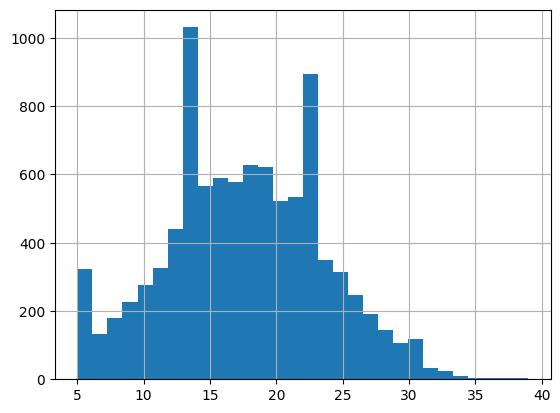

In [ ]:
orders_df["delivery_time_minutes"].hist(bins=30)


### Hourly Spike Validation

<Axes: xlabel='hour'>

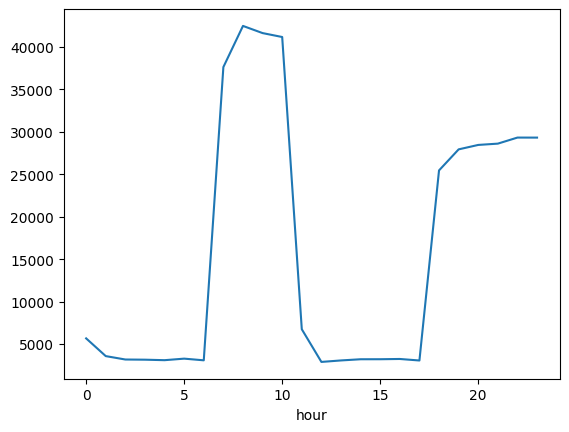

In [61]:
events_df["hour"] = events_df["event_time"].dt.hour

events_df.groupby("hour")["event_id"].count().plot()


### Weekend Spike Val

<Axes: xlabel='weekday'>

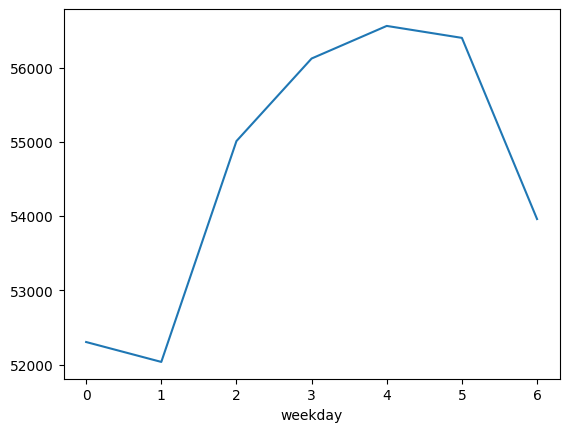

In [62]:
events_df["weekday"] = events_df["event_time"].dt.weekday

events_df.groupby("weekday")["event_id"].count().plot()


### Churn Check

In [63]:
last_date = events_df["event_time"].max()

last_activity = events_df.groupby("user_id")["event_time"].max()

churned = last_activity[last_date - last_activity > pd.Timedelta(days=14)]

print("Churn Rate:", len(churned) / len(last_activity))


Churn Rate: 0.6070234113712375


In [64]:
users_df["user_type"].value_counts(normalize=True)


user_type
occasional    0.3980
regular       0.3027
one_time      0.1962
power         0.1031
Name: proportion, dtype: float64

In [65]:
users_with_orders = orders_df["user_id"].nunique()
total_users = users_df["user_id"].nunique()

print("Users who ever ordered:", users_with_orders / total_users)


Users who ever ordered: 0.5632


In [66]:
churned_30 = last_activity[last_date - last_activity > pd.Timedelta(days=30)]
print("30-day churn:", len(churned_30) / len(last_activity))


30-day churn: 0.4262123745819398
